In [ ]:
!ls /content

sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# CHANGE 1: Update this zip path to your own file in Drive
zip_path = '/content/drive/MyDrive/Colab Notebooks/ham10000.zip'

# CHANGE 2: Local extraction folder in Colab
extract_path = '/content/ham10000_data'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /content/ham10000_data


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
!pip install -q tensorflow scikit-learn seaborn scipy pillow

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


from sklearn.utils import resample

print("All imports done")

All imports done


# Reading the CSV file

In [ ]:
skin_df = pd.read_csv(os.path.join(extract_path, 'HAM10000_metadata.csv'))

In [ ]:
print(skin_df.head())

print(skin_df.tail())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
         lesion_id      image_id     dx dx_type   age     sex localization
10010  HAM_0002867  ISIC_0033084  akiec   histo  40.0    male      abdomen
10011  HAM_0002867  ISIC_0033550  akiec   histo  40.0    male      abdomen
10012  HAM_0002867  ISIC_0033536  akiec   histo  40.0    male      abdomen
10013  HAM_0000239  ISIC_0032854  akiec   histo  80.0    male         face
10014  HAM_0003521  ISIC_0032258    mel   histo  70.0  female         back


In [ ]:
print("\nDisease types:", skin_df['dx'].unique())  # Listing the unique diseases. Expected output: classes = 7


Disease types: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


# Label encoding to convert text labels to numbers

In [ ]:
le = LabelEncoder()
skin_df['label'] = le.fit_transform(skin_df['dx'])

# To show the mapping
print("Class labels:")
for i, name in enumerate(le.classes_):
    print("{} -> {}".format(i,name))

Class labels:
0 -> akiec
1 -> bcc
2 -> bkl
3 -> df
4 -> mel
5 -> nv
6 -> vasc


In [ ]:
print(skin_df.sample(10))

        lesion_id      image_id   dx    dx_type   age     sex  \
1617  HAM_0007180  ISIC_0033272  mel      histo  65.0    male   
2296  HAM_0004428  ISIC_0025317  mel      histo  80.0    male   
2155  HAM_0001744  ISIC_0029353  mel      histo  60.0    male   
3265  HAM_0003382  ISIC_0028862   nv  follow_up  50.0  female   
6249  HAM_0002055  ISIC_0027520   nv  follow_up  40.0  female   
4617  HAM_0001854  ISIC_0027013   nv  follow_up  35.0  female   
4988  HAM_0004218  ISIC_0028256   nv  follow_up  60.0    male   
4363  HAM_0000975  ISIC_0029267   nv  follow_up  40.0  female   
7673  HAM_0007265  ISIC_0033933   nv      histo  20.0    male   
9506  HAM_0002755  ISIC_0033159   nv  consensus  65.0    male   

         localization  label  
1617             face      4  
2296  upper extremity      4  
2155             back      4  
3265  lower extremity      5  
6249  lower extremity      5  
4617            trunk      5  
4988            trunk      5  
4363            trunk      5  
7673 

In [ ]:
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2


# Data visualization using plots

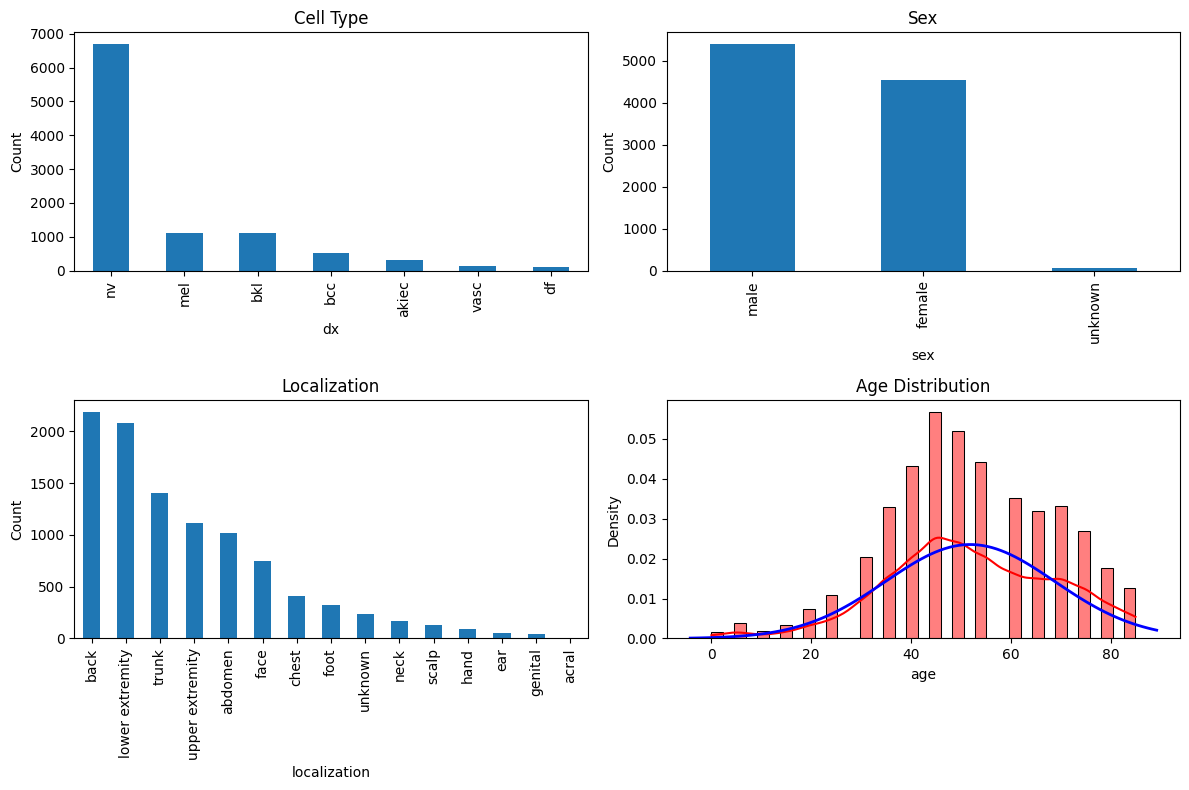

In [ ]:
fig = plt.figure(figsize=(12, 8))

# ----- Plot 1: Plotting the disease types (or Cell Types) -------
ax1 = fig.add_subplot(221)
skin_df['dx'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count')
ax1.set_title('Cell Type')

# ------ Plot 2: Plotting to see the distribution of gender -----
ax2 = fig.add_subplot(222)
skin_df['sex'].value_counts().plot(kind='bar', ax=ax2)
ax2.set_ylabel('Count')
ax2.set_title('Sex')

# --- Plot 3: Plotting localization -------
ax3 = fig.add_subplot(223)
skin_df['localization'].value_counts().plot(kind='bar', ax=ax3)
ax3.set_ylabel('Count')
ax3.set_title('Localization')

# ----- Plot 4: Age Distribution ------
ax4 = fig.add_subplot(224)

#sample_age = skin_df[pd.notnull(skin_df['age'])]
age_data = skin_df['age'].dropna()

# Using histogram + KDE for better visualization of whether the data is symmetric or skewed
sns.histplot(age_data, kde=True, stat='density', color='red', ax=ax4)

# Displaing the fitted normal curve
mean, std_dev = stats.norm.fit(age_data)
xmin, xmax = ax4.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std_dev)

ax4.plot(x, p, linewidth=2, color = 'blue')      # the normal curve
ax4.set_title('Age Distribution')
ax4.set_xlabel('age')
ax4.set_ylabel('Density')

plt.tight_layout()
plt.show()


In the age distribution curve, we see that our data is not following the normal curve (which is blue in colour). Hence we, can infer that it is not symmetric

# Visualising the distribution of data into various classes

In [ ]:
print(type(skin_df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print(skin_df.shape)

(10015, 8)


In [ ]:
print(skin_df['label'].value_counts())

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


**From the graph and the values here, we can infer that the data is imbalanced.**

# Reading all image paths (all .jpg files in both of the image folders)

In [ ]:
image_path = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join('ham10000_data/HAM10000_images_part_*', '*.jpg'))
}

# Adding a new column named 'path' to the dataframe
skin_df['path'] = skin_df['image_id'].map(image_path.get)

# Now, we drop the rows where image was not found
skin_df = skin_df.dropna(subset=['path'])

print(f"Total images available: {len(skin_df)}")

Total images available: 10015


In [ ]:
skin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   label         10015 non-null  int64  
 8   path          10015 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 704.3+ KB


Therefore, we can see that all rows have an image. In other words, there are no rows without one.

# The following shows the number of images for each disease

In [ ]:
print(skin_df['dx'].value_counts())



dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Again we can see that there is some imbalance.

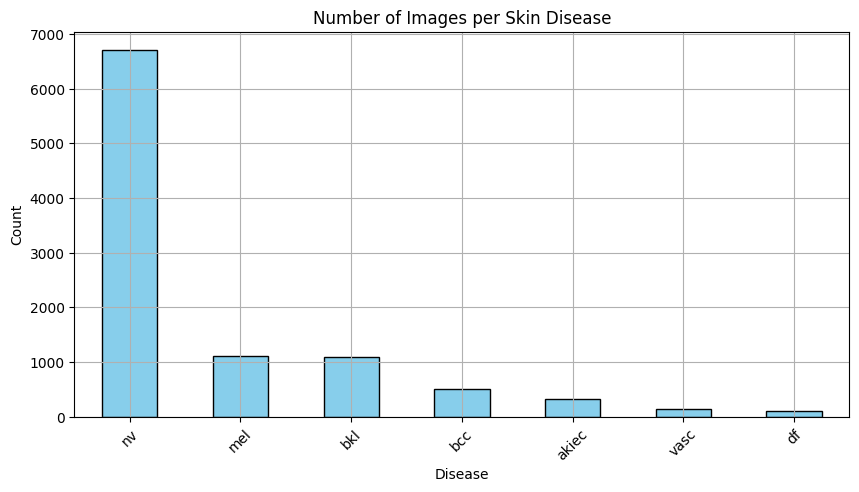

In [ ]:
# Ploting a bar chart
plt.figure(figsize=(10, 5))
skin_df['dx'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Number of Images per Skin Disease")
plt.ylabel("Count")
plt.xlabel("Disease")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Spliting the data into 70% for training and 15% for validation and 15% for testing

In [ ]:
X_paths = skin_df['path'].values
Y = skin_df['label'].values

X_train_val_paths, X_test_paths, y_train_val_labels, y_test_labels = train_test_split(
    X_paths, Y, test_size=0.15, random_state=42, stratify=Y
)

X_train_paths, X_val_paths, y_train_labels, y_val_labels = train_test_split(
    X_train_val_paths, y_train_val_labels, test_size=0.1765, random_state=42, stratify=y_train_val_labels
)


In [ ]:
print("\nTrain samples:", len(X_train_paths))
print("Validation samples:", len(X_val_paths))
print("Test samples:", len(X_test_paths))


Train samples: 7009
Validation samples: 1503
Test samples: 1503


# Now, below we compute the class weights

Since the data is skewed, we try to compute the class weights such that the rare classes get more weightage than the common ones.

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(4.372426699937617), 1: np.float64(2.7813492063492062), 2: np.float64(1.3020620471855842), 3: np.float64(12.51607142857143), 4: np.float64(1.2853475151292866), 5: np.float64(0.2133572798392743), 6: np.float64(10.113997113997113)}


## Data Augmentation

In [ ]:
SIZE = 224
BATCH_SIZE = 16

In [ ]:
train_data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_data_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_df = pd.DataFrame({
    'path': X_train_paths,
    'label': y_train_labels.astype(str)
})

val_df = pd.DataFrame({
    'path': X_val_paths,
    'label': y_val_labels.astype(str)
})

test_df = pd.DataFrame({
    'path': X_test_paths,
    'label': y_test_labels.astype(str)
})

train_generator = train_data_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=(SIZE, SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_data_gen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=(SIZE, SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_data_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=(SIZE, SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 7009 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


# Now, we build the EfficientNet model

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(SIZE, SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,411,306 (16.83 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# We now set the callbacks

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
]


### Explanation for myself:

The **ReduceLROnPlateau** monitors our model's accuracy on validation data i.e., *monitor='val_accuracy'*. If this accuracy doesnot improve for like 3 epochs in a row, since *patience=3*, it reduces the learning rate into half, since *factor=0.5*.

The **EarlyStopping** also watches the *val_accuracy*. and if that doesnot get better for 7 consecutive epochs, since *patience=7*, it completely stops the training. This then loads the model's best weights from earlier, since we do: *restore_best_weights=True*, so we donot have to end up with an overfitted or even a worse version.

## Model Training

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 213s 413ms/step - accuracy: 0.3537 - loss: 1.8018 - val_accuracy: 0.3513 - val_loss: 1.6098 - learning_rate: 0.0010
Epoch 2/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 144s 328ms/step - accuracy: 0.3868 - loss: 1.5654 - val_accuracy: 0.3533 - val_loss: 1.4311 - learning_rate: 0.0010
Epoch 3/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 135s 307ms/step - accuracy: 0.4076 - loss: 1.4688 - val_accuracy: 0.6727 - val_loss: 0.9970 - learning_rate: 0.0010
Epoch 4/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 133s 302ms/step - accuracy: 0.4343 - loss: 1.3980 - val_accuracy: 0.4398 - val_loss: 1.3828 - learning_rate: 0.0010
Epoch 5/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 133s 302ms/step - accuracy: 0.4433 - loss: 1.3353 - val_accuracy: 0.6434 - val_loss: 0.9363 - learning_rate: 0.0010
Epoch 6/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4727 - loss: 1.3394
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
439/439 ━━━━━━━━━━━━━━━━━━━━ 134s 304ms/step - accuracy:

# We finally plot the resuts

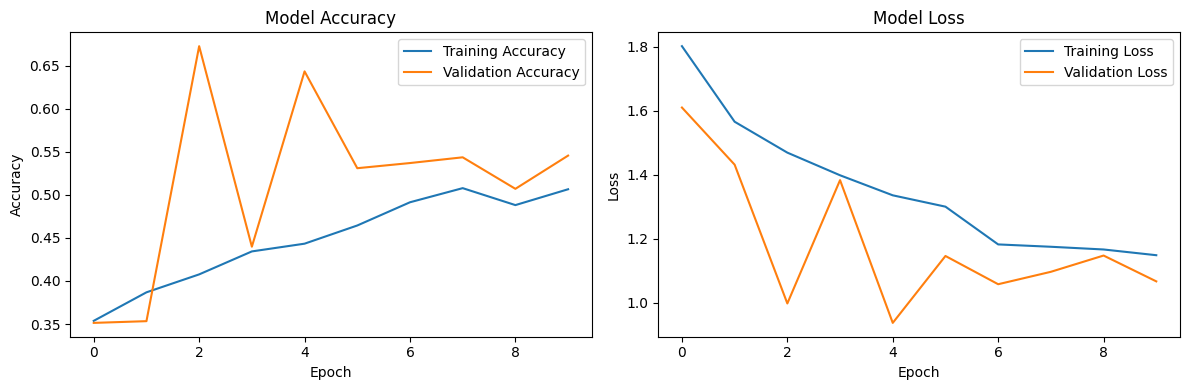

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Test evaluation

Test Loss: 1.005345344543457
Test Accuracy: 0.6673319935798645
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 200ms/step


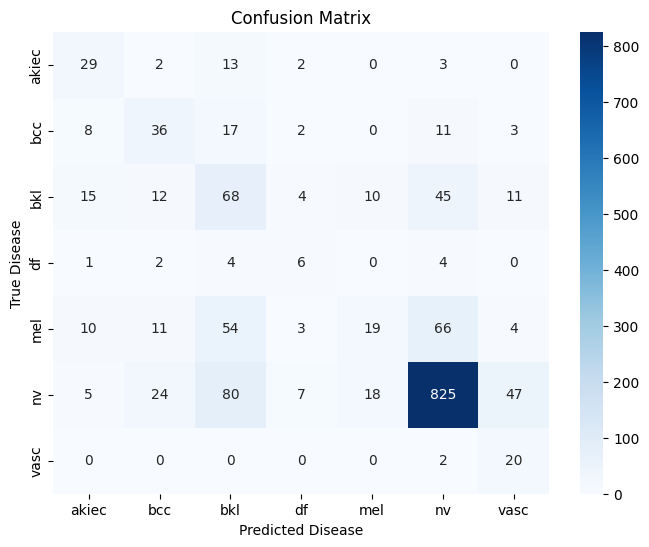


Classification Report:
              precision    recall  f1-score   support

       akiec       0.43      0.59      0.50        49
         bcc       0.41      0.47      0.44        77
         bkl       0.29      0.41      0.34       165
          df       0.25      0.35      0.29        17
         mel       0.40      0.11      0.18       167
          nv       0.86      0.82      0.84      1006
        vasc       0.24      0.91      0.37        22

    accuracy                           0.67      1503
   macro avg       0.41      0.52      0.42      1503
weighted avg       0.70      0.67      0.67      1503



In [ ]:
score = model.evaluate(test_generator, verbose=0)
print("Test Loss:", score[0])
print("Test Accuracy:", score[1])

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("True Disease")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

In [ ]:
print(skin_df['label'].value_counts())

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

img_path = '/content/basal-cell-carcinoma-0087.jpg'

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
pred_class = np.argmax(preds, axis=1)[0]
pred_label = le.inverse_transform([pred_class])[0]

print("Predicted class:", pred_label)
print("Probabilities:", preds[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted class: nv
Probabilities: [0.01465167 0.10803784 0.16827333 0.02435349 0.07730773 0.38911355
 0.21826243]
